<a href="https://colab.research.google.com/github/its-abhinav-mandloi/DRL-Assignment-1/blob/main/Part%20-%202%20DP/Part2_DroneRescue_DP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚁 Part 2: Autonomous Drone Rescue Using Dynamic Programming

**Course**: Deep Reinforcement Learning (DRL NSP4)  
**Assignment**: Assignment 1 — Part 2 (DP)  
**Group ID**: 151 (last digit = 1)  
**Total Marks**: 5  


## Module Setup


In [12]:
"""
=============================================================================
Part 2: Autonomous Drone Rescue Using Dynamic Programming
=============================================================================
Course : Deep Reinforcement Learning (DRL NSP4)
Assignment : Assignment 1 — Part 2 (DP)
Group ID : 151 (last digit = 1)
=============================================================================
Configuration (derived from Group ID 151):
  - Grid Size      : 5×5
  - Rescue Targets  : 2
  - Charging Stations: 1
  - Danger Zones    : 3
  - Blocked Cells   : 2
  - Max Battery     : 15 (odd last digit)
  - Wind Probability: 20% (last digit 0-4)
  - Max Steps       : 50 (5×5 grid)
=============================================================================
"""

'\n=============================================================================\nPart 2: Autonomous Drone Rescue Using Dynamic Programming\n=============================================================================\nCourse : Deep Reinforcement Learning (DRL NSP4)\nAssignment : Assignment 1 — Part 2 (DP)\nGroup ID : 151 (last digit = 1)\n=============================================================================\nConfiguration (derived from Group ID 151):\n  - Grid Size      : 5×5\n  - Rescue Targets  : 2\n  - Charging Stations: 1\n  - Danger Zones    : 3\n  - Blocked Cells   : 2\n  - Max Battery     : 15 (odd last digit)\n  - Wind Probability: 20% (last digit 0-4)\n  - Max Steps       : 50 (5×5 grid)\n=============================================================================\n'

## Imports and Setup


In [13]:
# Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from itertools import product
import time
import os
import copy

# Virtual Lab Info (update these when running in virtual lab)
print("=" * 60)
print("Part 2: Autonomous Drone Rescue Using Dynamic Programming")
print("=" * 60)
print(f"Group ID        : 151")
print(f"Execution Time  : {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Virtual Machine ID: {os.uname().nodename}")
print("=" * 60)

Part 2: Autonomous Drone Rescue Using Dynamic Programming
Group ID        : 151
Execution Time  : 2026-06-03 18:18:50
Virtual Machine ID: 7e23e2088f66


## Environment Configuration


In [14]:
# Environment Configuration

# Grid layout for Group ID 151 (5×5)
# S = Start, F = Free, D = Danger, R = Rescue
# C = Charging, W = Wind, X = Blocked
GRID_LAYOUT = [
    ['S', 'F', 'W', 'F', 'D'],   # Row 0
    ['F', 'X', 'F', 'R', 'F'],   # Row 1
    ['D', 'F', 'C', 'F', 'W'],   # Row 2
    ['F', 'D', 'F', 'F', 'F'],   # Row 3
    ['X', 'F', 'R', 'F', 'F'],   # Row 4
]

# Configuration constants
GRID_ROWS = 5
GRID_COLS = 5
MAX_BATTERY = 15
WIND_PROB = 0.20
MAX_STEPS = 50
GAMMA = 0.95          # Discount factor
THETA = 1e-3          # Convergence threshold

# Rewards
REWARD_RESCUE = 20
REWARD_DANGER = -10
REWARD_BATTERY_DEAD = -20
REWARD_CHARGING = 5
REWARD_MOVE = -1

# Actions: 0=Up, 1=Down, 2=Left, 3=Right, 4=Hover
ACTIONS = {
    0: (-1, 0),   # Up
    1: (1, 0),    # Down
    2: (0, -1),   # Left
    3: (0, 1),    # Right
    4: (0, 0),    # Hover
}
ACTION_NAMES = {0: '↑', 1: '↓', 2: '←', 3: '→', 4: '●'}
ACTION_LABELS = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right', 4: 'Hover'}

# Find rescue target positions from grid
RESCUE_POSITIONS = []
for r in range(GRID_ROWS):
    for c in range(GRID_COLS):
        if GRID_LAYOUT[r][c] == 'R':
            RESCUE_POSITIONS.append((r, c))
NUM_RESCUE = len(RESCUE_POSITIONS)

print("\n--- Environment Configuration ---")
print(f"Grid Size       : {GRID_ROWS}×{GRID_COLS}")
print(f"Max Battery     : {MAX_BATTERY}")
print(f"Wind Probability: {WIND_PROB*100:.0f}%")
print(f"Max Steps       : {MAX_STEPS}")
print(f"Discount Factor : {GAMMA}")
print(f"Convergence θ   : {THETA}")
print(f"Rescue Targets  : {RESCUE_POSITIONS}")
print(f"Num Rescue      : {NUM_RESCUE}")

# Print grid
print("\n--- Grid Layout ---")
print("     ", "  ".join([f"Col{c}" for c in range(GRID_COLS)]))
for r in range(GRID_ROWS):
    row_str = f"Row{r} "
    for c in range(GRID_COLS):
        row_str += f"[ {GRID_LAYOUT[r][c]} ] "
    print(row_str)


--- Environment Configuration ---
Grid Size       : 5×5
Max Battery     : 15
Wind Probability: 20%
Max Steps       : 50
Discount Factor : 0.95
Convergence θ   : 0.001
Rescue Targets  : [(1, 3), (4, 2)]
Num Rescue      : 2

--- Grid Layout ---
      Col0  Col1  Col2  Col3  Col4
Row0 [ S ] [ F ] [ W ] [ F ] [ D ] 
Row1 [ F ] [ X ] [ F ] [ R ] [ F ] 
Row2 [ D ] [ F ] [ C ] [ F ] [ W ] 
Row3 [ F ] [ D ] [ F ] [ F ] [ F ] 
Row4 [ X ] [ F ] [ R ] [ F ] [ F ] 


## MDP Formulation and Design

### State Space Definition
Each state is a tuple: `(row, col, battery, rescue_0, rescue_1, charge_0_claimed)`

- **row**: Drone's row position (0 to 4)
- **col**: Drone's column position (0 to 4)
- **battery**: Current battery level (0 to 15)
- **rescue_0**: Binary status of first target (0=not rescued, 1=rescued)
- **rescue_1**: Binary status of second target (0=not rescued, 1=rescued)
- **charge_0_claimed**: Binary flag showing whether the charging-station reward has already been claimed (prevents reward farming)

**Example states:**
- `(0, 0, 15, 0, 0, 0)`: Start position, full battery, no targets rescued, charger bonus unclaimed
- `(1, 3, 10, 1, 0, 0)`: At rescue target location, battery=10, first target rescued
- `(2, 2, 15, 0, 0, 1)`: On charging station, full battery, charging reward already claimed

### Action Space
All 5 actions are always valid:
- 0: **Up** (-1 row, same col)
- 1: **Down** (+1 row, same col)
- 2: **Left** (same row, -1 col)
- 3: **Right** (same row, +1 col)
- 4: **Hover** (stay in place)

Invalid moves (boundary, blocked cells) result in staying in place while still consuming 1 battery.

### Transition Dynamics

**Wind Cells (W)**: When on a wind cell and taking a movement action:
- P(intended direction) = 0.80 + 0.05 = **0.85** (20% wind probability)
- P(each other direction) = 0.05 each
- Hover is NOT affected by wind

**Charging Stations (C)**:
- Entering: battery becomes full (MAX_BATTERY=15), reward = +5 only the first time the charging station bonus is claimed
- Hovering: battery increases by 2 (capped at max), reward = -1 regular action cost

**Rescue Targets (R)**:
- First visit: rescue target disappears, cell becomes free, reward = +20
- Subsequent visits: treated as free cell, reward = -1

**Danger Zones (D)**:
- Entering: reward = -10 (no episode termination)

**Terminal States**:
- Battery reaches 0: episode ends, reward = -20
- All targets rescued: episode ends successfully

### Reward Structure
| Event | Reward |
|-------|--------|
| Rescue target reached | +20 |
| Enter charging station | +5 |
| Hover on charging station | -1 (battery +2) |
| Enter danger zone | -10 |
| Battery exhausted | -20 |
| Regular movement/hover | -1 |

### Grid Configuration (Group ID 151, ends with 1 → 5×5 grid)
- 2 rescue targets at (1,3) and (4,2)
- 1 charging station at (2,2)
- 3 danger zones at (0,4), (2,0), (3,1)
- 2 blocked cells at (1,1), (4,0)
- Wind zones at (0,2), (2,4) with 20% disturbance probability


## Drone Rescue Environment Class


In [24]:
# Drone Rescue Environment Class

class DroneRescueEnv:
    """
    Custom grid-world environment for autonomous drone rescue.

    State: (row, col, battery, rescue_0_status, rescue_1_status, charge_0_claimed)
      - row, col: drone position on the grid
      - battery: current battery level (0 to MAX_BATTERY)
      - rescue_i_status: 0 = not rescued, 1 = rescued
      - charge_i_claimed: 0 = charging bonus not yet claimed, 1 = claimed

    Actions: 0=Up, 1=Down, 2=Left, 3=Right, 4=Hover
    """

    def __init__(self):
        """Initialize the drone rescue environment."""
        self.grid = [row[:] for row in GRID_LAYOUT]  # Deep copy
        self.rows = GRID_ROWS
        self.cols = GRID_COLS
        self.max_battery = MAX_BATTERY
        self.wind_prob = WIND_PROB
        self.max_steps = MAX_STEPS
        self.rescue_positions = RESCUE_POSITIONS[:]
        self.num_rescue = NUM_RESCUE

        # Find special positions
        self.start_pos = (0, 0)  # Fixed per assignment
        self.blocked_cells = set()
        self.danger_cells = set()
        self.wind_cells = set()
        self.charging_cells = set()
        self.charging_positions = []

        for r in range(self.rows):
            for c in range(self.cols):
                cell = self.grid[r][c]
                if cell == 'X':
                    self.blocked_cells.add((r, c))
                elif cell == 'D':
                    self.danger_cells.add((r, c))
                elif cell == 'W':
                    self.wind_cells.add((r, c))
                elif cell == 'C':
                    self.charging_cells.add((r, c))
                    self.charging_positions.append((r, c))

        self.num_charging = len(self.charging_positions)

        # Current state (for interactive simulation)
        self.state = None
        self.steps = 0
        self.reset()

    def reset(self):
        """Reset the environment to initial state.

        Returns:
            state: tuple (row, col, battery, rescue_0, rescue_1, charge_0_claimed)
        """
        rescue_status = tuple([0] * self.num_rescue)
        charge_status = tuple([0] * self.num_charging)
        self.state = (self.start_pos[0], self.start_pos[1], self.max_battery) + rescue_status + charge_status
        self.steps = 0
        return self.state

    def _split_status(self, state):
        """Split rescue and charging-bonus flags from a full state tuple."""
        rescue_end = 3 + self.num_rescue
        charge_end = rescue_end + self.num_charging
        rescue_status = tuple(state[3:rescue_end])
        charge_status = tuple(state[rescue_end:charge_end])
        return rescue_status, charge_status

    def _get_cell_type(self, row, col, rescue_status):
        """Get the effective cell type considering rescue status.

        If a rescue target has been rescued, it becomes a Free cell.
        """
        cell = self.grid[row][col]
        if cell == 'R':
            # Check if this rescue target has been rescued
            idx = self.rescue_positions.index((row, col))
            if rescue_status[idx] == 1:
                return 'F'  # Already rescued → treat as free
        return cell

    def _move_result(self, row, col, action):
        """Compute the new position after taking an action.

        Handles boundary checking and blocked cells.
        Returns (new_row, new_col).
        """
        if action == 4:  # Hover
            return row, col

        dr, dc = ACTIONS[action]
        new_r, new_c = row + dr, col + dc

        # Check boundaries
        if new_r < 0 or new_r >= self.rows or new_c < 0 or new_c >= self.cols:
            return row, col  # Stay in place

        # Check blocked cells
        if (new_r, new_c) in self.blocked_cells:
            return row, col  # Stay in place

        return new_r, new_c

    def _compute_transition(self, row, col, battery, rescue_status, charge_status, action):
        """Compute the outcome of taking an action from a given state.

        Returns a list of (probability, next_state, reward, done) tuples.
        This handles wind stochasticity.
        """
        results = {}  # next_state -> (probability, reward, done)

        # --- Determine if wind affects this action ---
        current_cell = self._get_cell_type(row, col, rescue_status)
        is_wind = (current_cell == 'W')
        is_movement = (action != 4)  # Hover is NOT a movement action

        if is_wind and is_movement:
            # Wind stochasticity: with prob WIND_PROB, direction is random
            # Intended direction succeeds with prob (1 - WIND_PROB)
            # Random direction (uniform over 4 movement actions) with prob WIND_PROB

            movement_actions = [0, 1, 2, 3]  # Up, Down, Left, Right
            for actual_action in movement_actions:
                if actual_action == action:
                    prob = (1 - self.wind_prob) + (self.wind_prob / 4)
                else:
                    prob = self.wind_prob / 4

                new_r, new_c = self._move_result(row, col, actual_action)
                next_state, reward, done = self._apply_action_outcome(
                    new_r, new_c, battery, rescue_status, charge_status
                )

                # Accumulate probabilities for same next_state
                if next_state in results:
                    old_prob, old_reward, old_done = results[next_state]
                    results[next_state] = (old_prob + prob, old_reward, old_done)
                else:
                    results[next_state] = (prob, reward, done)
        else:
            # Deterministic transition (no wind or hover)
            new_r, new_c = self._move_result(row, col, action)
            next_state, reward, done = self._apply_action_outcome(
                new_r, new_c, battery, rescue_status, charge_status, is_hover=(action == 4)
            )
            results[next_state] = (1.0, reward, done)

        return [(prob, ns, rew, dn) for ns, (prob, rew, dn) in results.items()]

    def _apply_action_outcome(self, new_r, new_c, battery, rescue_status, charge_status, is_hover=False):
        """Apply the outcome of landing on a cell after a move.

        Returns (next_state, reward, done).
        """
        rescue_status = list(rescue_status)
        charge_status = list(charge_status)
        reward = REWARD_MOVE  # Default: -1 per action
        done = False

        dest_cell = self._get_cell_type(new_r, new_c, tuple(rescue_status))

        # --- Battery update ---
        if is_hover and dest_cell == 'C':
            # Hovering on a charging station restores battery, but the +5
            # reward is only for reaching/entering the station.
            new_battery = min(battery + 2, self.max_battery)
        elif dest_cell == 'C' and not is_hover:
            # Enter charging station: battery becomes full
            new_battery = self.max_battery
            charge_idx = self.charging_positions.index((new_r, new_c))
            if charge_status[charge_idx] == 0:
                reward = REWARD_CHARGING  # +5 (reached charging station)
                charge_status[charge_idx] = 1
        else:
            # Regular action: -1 battery
            new_battery = battery - 1

        # --- Check for rescue target ---
        if dest_cell == 'R':
            idx = self.rescue_positions.index((new_r, new_c))
            if rescue_status[idx] == 0:
                rescue_status[idx] = 1  # Mark as rescued
                reward = REWARD_RESCUE  # +20

        # --- Check for danger zone ---
        if dest_cell == 'D':
            reward = REWARD_DANGER  # -10

        # --- Check battery exhaustion ---
        if new_battery <= 0:
            new_battery = 0
            reward = REWARD_BATTERY_DEAD  # -20
            done = True

        # --- Check if all rescued ---
        if all(rs == 1 for rs in rescue_status):
            done = True

        next_state = (new_r, new_c, new_battery) + tuple(rescue_status) + tuple(charge_status)
        return next_state, reward, done

    def step(self, action):
        """Execute one action in the environment.

        Args:
            action: int (0=Up, 1=Down, 2=Left, 3=Right, 4=Hover)

        Returns:
            next_state, reward, done, info
        """
        if self.state is None:
            raise ValueError("Environment not initialized. Call reset() first.")

        row, col, battery = self.state[0], self.state[1], self.state[2]
        rescue_status, charge_status = self._split_status(self.state)

        # Battery already 0 → already done
        if battery == 0:
            return self.state, 0, True, {"reason": "already_terminated"}

        transitions = self._compute_transition(row, col, battery, rescue_status, charge_status, action)

        # For simulation: sample from transitions
        probs = [t[0] for t in transitions]
        idx = np.random.choice(len(transitions), p=probs)
        _, next_state, reward, done = transitions[idx]

        self.state = next_state
        self.steps += 1

        # Check step limit
        if self.steps >= self.max_steps and not done:
            done = True

        info = {
            "steps": self.steps,
            "action": ACTION_LABELS[action],
        }

        return next_state, reward, done, info

    def get_transition_prob(self, state, action):
        """Get transition probabilities for Dynamic Programming.

        Args:
            state: tuple (row, col, battery, rescue_0, rescue_1, charge_0_claimed)
            action: int (0-4)

        Returns:
            list of (probability, next_state, reward, done) tuples
        """
        row, col, battery = state[0], state[1], state[2]
        rescue_status, charge_status = self._split_status(state)

        if self.is_terminal(state):
            return [(1.0, state, 0, True)]

        return self._compute_transition(row, col, battery, rescue_status, charge_status, action)

    def get_all_states(self):
        """Enumerate all valid states for DP.

        Returns:
            list of state tuples
        """
        states = []
        rescue_combos = list(product([0, 1], repeat=self.num_rescue))
        charge_combos = list(product([0, 1], repeat=self.num_charging))

        for r in range(self.rows):
            for c in range(self.cols):
                if (r, c) in self.blocked_cells:
                    continue  # Drone can never be on a blocked cell
                for bat in range(0, self.max_battery + 1):
                    for rc in rescue_combos:
                        for cc in charge_combos:
                            state = (r, c, bat) + rc + cc
                            states.append(state)
        return states

    def is_terminal(self, state):
        """Check if a state is terminal."""
        battery = state[2]
        rescue_status, _ = self._split_status(state)

        if battery == 0:
            return True
        if all(rs == 1 for rs in rescue_status):
            return True
        return False


    def get_valid_actions(self, state):
        """Return all valid actions available from a given state.

        Per assignment: all 5 actions (Up, Down, Left, Right, Hover) are always
        available. Invalid moves (boundary, blocked cell) remain valid actions but
        result in staying in place while consuming battery.

        Args:
            state: tuple (row, col, battery, *rescue_statuses)

        Returns:
            list of action indices [0, 1, 2, 3, 4]
        """
        # All actions are valid; the environment handles invalid moves by staying in place
        return list(ACTIONS.keys())
    def render(self, state=None):
        """Print the grid with drone position and status.

        Args:
            state: optional state tuple to render. If None, uses self.state.
        """
        if state is None:
            state = self.state

        row, col, battery = state[0], state[1], state[2]
        rescue_status, charge_status = self._split_status(state)

        print(f"\nBattery: {battery}/{self.max_battery} | "
              f"Rescued: {list(rescue_status)} | "
              f"Charging bonus claimed: {list(charge_status)} | "
              f"Position: ({row},{col})")
        print("     " + "  ".join([f"C{c}" for c in range(self.cols)]))

        for r in range(self.rows):
            row_str = f"R{r}  "
            for c in range(self.cols):
                if r == row and c == col:
                    row_str += "[ 🚁] "
                else:
                    cell = self._get_cell_type(r, c, rescue_status)
                    symbols = {
                        'S': ' S ', 'F': ' · ', 'D': ' ☠ ',
                        'R': ' 🧑', 'C': ' ⚡', 'W': ' 💨',
                        'X': ' ▓ '
                    }
                    row_str += f"[{symbols.get(cell, ' ? ')}] "
            print(row_str)
        print()

## Test the Environment


In [23]:
# Test the Environment
print("\n" + "=" * 60)
print("DELIVERABLE 1: Custom Drone Rescue Environment")
print("=" * 60)

env = DroneRescueEnv()

# Display initial state
print("\n--- Initial State ---")
state = env.reset()
env.render()

# Show environment info
print(f"Total valid states: {len(env.get_all_states())}")
print(f"Blocked cells: {env.blocked_cells}")
print(f"Danger cells: {env.danger_cells}")
print(f"Wind cells: {env.wind_cells}")
print(f"Charging cells: {env.charging_cells}")
print(f"Rescue positions: {env.rescue_positions}")

# Manual test: take a few actions
print("\n--- Manual Test: Taking Actions ---")
state = env.reset()
test_actions = [3, 1, 1, 3, 3]  # Right, Down, Down, Right, Right
for a in test_actions:
    next_state, reward, done, info = env.step(a)
    print(f"Action: {ACTION_LABELS[a]:5s} → State: {next_state}, "
          f"Reward: {reward:+.0f}, Done: {done}")
    if done:
        break

# Test transition probabilities on a wind cell
print("\n--- Transition Probabilities from Wind Cell (0,2) ---")
test_state = (0, 2, 10, 0, 0, 0)  # On wind cell
for a in range(5):
    transitions = env.get_transition_prob(test_state, a)
    print(f"  Action {ACTION_LABELS[a]}:")
    for prob, ns, rew, dn in transitions:
        print(f"    P={prob:.3f} → state={ns}, R={rew:+.0f}, done={dn}")


DELIVERABLE 1: Custom Drone Rescue Environment

--- Initial State ---

Battery: 15/15 | Rescued: [0, 0] | Charging bonus claimed: [0] | Position: (0,0)
     C0  C1  C2  C3  C4
R0  [ 🚁] [ · ] [ 💨] [ · ] [ ☠ ] 
R1  [ · ] [ ▓ ] [ · ] [ 🧑] [ · ] 
R2  [ ☠ ] [ · ] [ ⚡] [ · ] [ 💨] 
R3  [ · ] [ ☠ ] [ · ] [ · ] [ · ] 
R4  [ ▓ ] [ · ] [ 🧑] [ · ] [ · ] 

Total valid states: 2944
Blocked cells: {(1, 1), (4, 0)}
Danger cells: {(2, 0), (0, 4), (3, 1)}
Wind cells: {(0, 2), (2, 4)}
Charging cells: {(2, 2)}
Rescue positions: [(1, 3), (4, 2)]

--- Manual Test: Taking Actions ---
Action: Right → State: (0, 1, 14, 0, 0, 0), Reward: -1, Done: False
Action: Down  → State: (0, 1, 13, 0, 0, 0), Reward: -1, Done: False
Action: Down  → State: (0, 1, 12, 0, 0, 0), Reward: -1, Done: False
Action: Right → State: (0, 2, 11, 0, 0, 0), Reward: -1, Done: False
Action: Right → State: (0, 3, 10, 0, 0, 0), Reward: -1, Done: False

--- Transition Probabilities from Wind Cell (0,2) ---
  Action Up:
    P=0.850 → state=(0,

## Value Iteration


In [17]:
# Value Iteration
print("\n" + "=" * 60)
print("DELIVERABLE 2: Dynamic Programming — Value Iteration")
print("=" * 60)

def value_iteration(env, gamma=GAMMA, theta=THETA):
    """
    Compute optimal value function V* and policy π* using Value Iteration.

    Args:
        env: DroneRescueEnv instance
        gamma: discount factor
        theta: convergence threshold

    Returns:
        V: dict mapping state → optimal value
        policy: dict mapping state → optimal action
        info: dict with convergence stats
    """
    # Step 1: Enumerate all states
    all_states = env.get_all_states()
    print(f"Total states to evaluate: {len(all_states)}")

    # Step 2: Initialize V(s) = 0 for all states
    V = {s: 0.0 for s in all_states}

    # Step 3: Value Iteration loop
    actions = list(ACTIONS.keys())  # [0, 1, 2, 3, 4]
    iteration = 0
    delta_history = []
    start_time = time.time()

    while True:
        delta = 0
        for s in all_states:
            if env.is_terminal(s):
                continue

            v_old = V[s]

            # Compute Q(s, a) for all actions
            action_values = []
            valid_actions = env.get_valid_actions(s)
            for a in valid_actions:
                q_value = 0
                transitions = env.get_transition_prob(s, a)
                for prob, next_state, reward, done in transitions:
                    if done:
                        q_value += prob * reward
                    else:
                        q_value += prob * (reward + gamma * V.get(next_state, 0.0))
                action_values.append(q_value)

            # Update V(s) = max Q(s, a)
            V[s] = max(action_values)
            delta = max(delta, abs(v_old - V[s]))

        iteration += 1
        delta_history.append(delta)

        # Print iteration info: every iteration for transparency
        print(f"  Iteration {iteration:4d} | delta = {delta:.8f}")

        if delta < theta:
            print(f"  → Converged at iteration {iteration}")
            break

    elapsed = time.time() - start_time

    # Step 4: Extract optimal policy
    policy = {}
    for s in all_states:
        if env.is_terminal(s):
            policy[s] = None
            continue

        best_action = None
        best_value = float('-inf')
        valid_actions = env.get_valid_actions(s)
        for a in valid_actions:
            q_value = 0
            transitions = env.get_transition_prob(s, a)
            for prob, next_state, reward, done in transitions:
                if done:
                    q_value += prob * reward
                else:
                    q_value += prob * (reward + gamma * V.get(next_state, 0.0))
            if q_value > best_value:
                best_value = q_value
                best_action = a
        policy[s] = best_action

    info = {
        "iterations": iteration,
        "runtime_seconds": elapsed,
        "final_delta": delta,
        "delta_history": delta_history,
        "num_states": len(all_states),
    }

    return V, policy, info


# Run Value Iteration
print("\nRunning Value Iteration...")
V_star, policy_star, vi_info = value_iteration(env)

print(f"\n--- Value Iteration Results ---")
print(f"Converged in {vi_info['iterations']} iterations")
print(f"Runtime: {vi_info['runtime_seconds']:.2f} seconds")
print(f"Final delta: {vi_info['final_delta']:.6f}")
print(f"Total states: {vi_info['num_states']}")

# Show value of initial state
initial_state = (0, 0, MAX_BATTERY, 0, 0, 0)
print(f"\nV*(start state) = {V_star.get(initial_state, 'N/A'):.4f}")
print(f"π*(start state) = {ACTION_LABELS.get(policy_star.get(initial_state), 'N/A')}")


DELIVERABLE 2: Dynamic Programming — Value Iteration

Running Value Iteration...
Total states to evaluate: 2944
  Iteration    1 | delta = 38.99525000
  Iteration    2 | delta = 19.00000000
  Iteration    3 | delta = 18.05000000
  Iteration    4 | delta = 17.14750000
  Iteration    5 | delta = 16.29012500
  Iteration    6 | delta = 13.88635323
  Iteration    7 | delta = 13.19203557
  Iteration    8 | delta = 0.62493116
  Iteration    9 | delta = 0.02960170
  Iteration   10 | delta = 0.00140203
  Iteration   11 | delta = 0.00006589
  → Converged at iteration 11

--- Value Iteration Results ---
Converged in 11 iterations
Runtime: 1.19 seconds
Final delta: 0.000066
Total states: 2944

V*(start state) = 30.1699
π*(start state) = Right


## Simulate Optimal Policy



--- Simulating Optimal Policy ---
Total steps: 8
Total reward: 40.00

Step-by-step trajectory:
  Step  0: pos=(0,0) bat=15 rescued=(0, 0) charge_bonus=(0,) → Right (R=-1)
  Step  1: pos=(0,1) bat=14 rescued=(0, 0) charge_bonus=(0,) → Right (R=-1)
  Step  2: pos=(0,2) bat=13 rescued=(0, 0) charge_bonus=(0,) → Down  (R=-1)
  Step  3: pos=(1,2) bat=12 rescued=(0, 0) charge_bonus=(0,) → Right (R=+20)
  Step  4: pos=(1,3) bat=11 rescued=(1, 0) charge_bonus=(0,) → Down  (R=-1)
  Step  5: pos=(2,3) bat=10 rescued=(1, 0) charge_bonus=(0,) → Left  (R=+5)
  Step  6: pos=(2,2) bat=15 rescued=(1, 0) charge_bonus=(1,) → Down  (R=-1)
  Step  7: pos=(3,2) bat=14 rescued=(1, 0) charge_bonus=(1,) → Down  (R=+20)
  Step  8: pos=(4,2) bat=13 rescued=(1, 1) charge_bonus=(1,) → END   (R=+0)


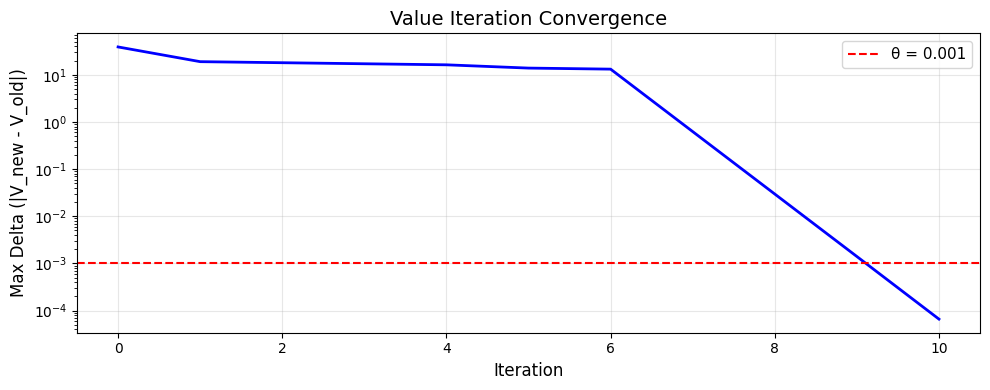

✅ Convergence plot saved.


In [18]:
# Simulate Optimal Policy
print("\n--- Simulating Optimal Policy ---")

def simulate_policy(env, policy, max_steps=MAX_STEPS):
    """Simulate the drone following the optimal policy.

    Returns:
        trajectory: list of (state, action, reward) tuples
        total_reward: cumulative reward
    """
    state = env.reset()
    trajectory = []
    total_reward = 0

    for step in range(max_steps):
        action = policy.get(state)
        if action is None:
            break

        next_state, reward, done, info = env.step(action)
        trajectory.append((state, action, reward))
        total_reward += reward

        if done:
            trajectory.append((next_state, None, 0))
            break
        state = next_state

    return trajectory, total_reward


np.random.seed(151)  # Reproducible rollout through stochastic wind cells
trajectory, total_reward = simulate_policy(env, policy_star)

print(f"Total steps: {len(trajectory) - 1}")
print(f"Total reward: {total_reward:.2f}")
print(f"\nStep-by-step trajectory:")
for i, (state, action, reward) in enumerate(trajectory):
    action_str = ACTION_LABELS.get(action, "END") if action is not None else "END"
    pos = f"({state[0]},{state[1]})"
    bat = state[2]
    rescued, charge_status = env._split_status(state)
    print(f"  Step {i:2d}: pos={pos} bat={bat:2d} rescued={rescued} "
          f"charge_bonus={charge_status} "
          f"→ {action_str:5s} (R={reward:+.0f})")

# Convergence plot
plt.figure(figsize=(10, 4))
plt.plot(vi_info['delta_history'], 'b-', linewidth=2)
plt.axhline(y=THETA, color='r', linestyle='--', label=f'θ = {THETA}')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Max Delta (|V_new - V_old|)', fontsize=12)
plt.title('Value Iteration Convergence', fontsize=14)
plt.legend(fontsize=11)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Convergence plot saved.")

## Policy Visualisation (Deliverable 3)



DELIVERABLE 3: Policy Visualisation

--- Policy at Full Battery (both targets unrescued) ---


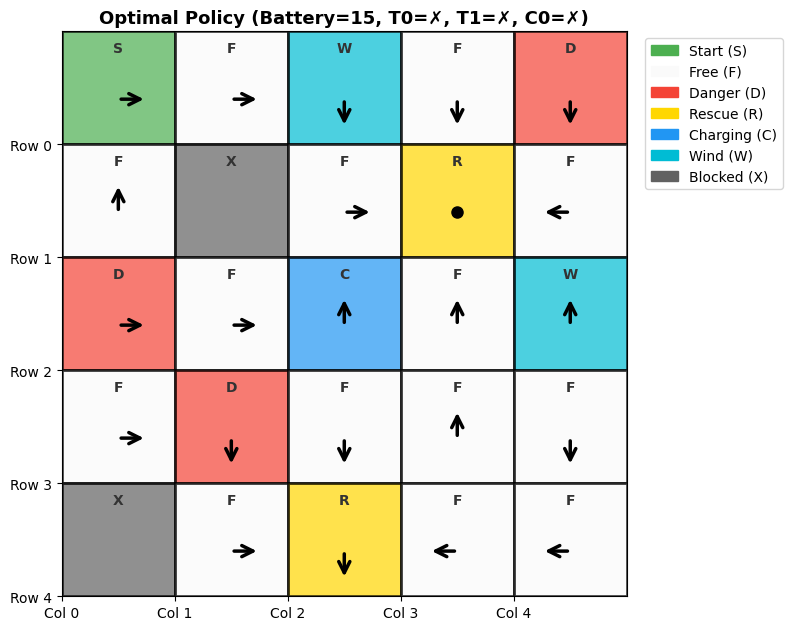


--- Policy at Low Battery (battery=3, both unrescued) ---


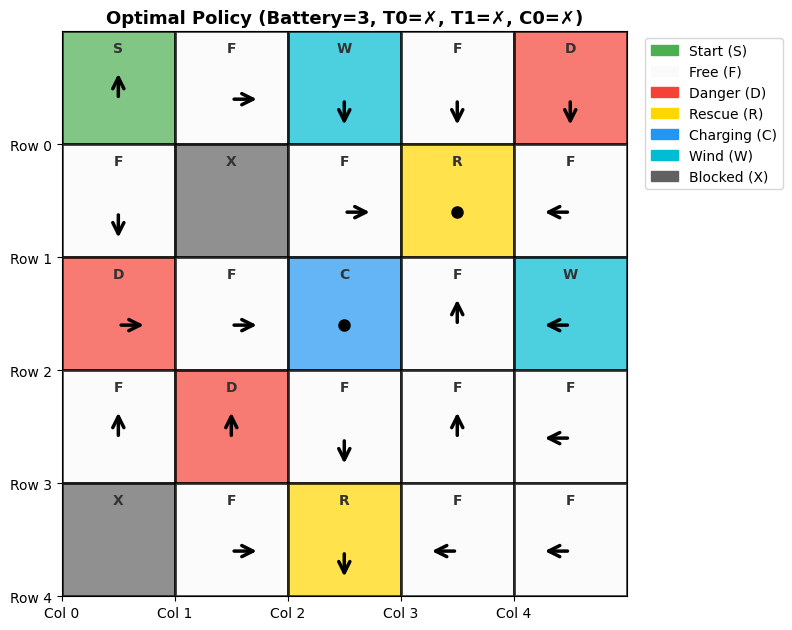


--- Policy after first target rescued (battery=10) ---


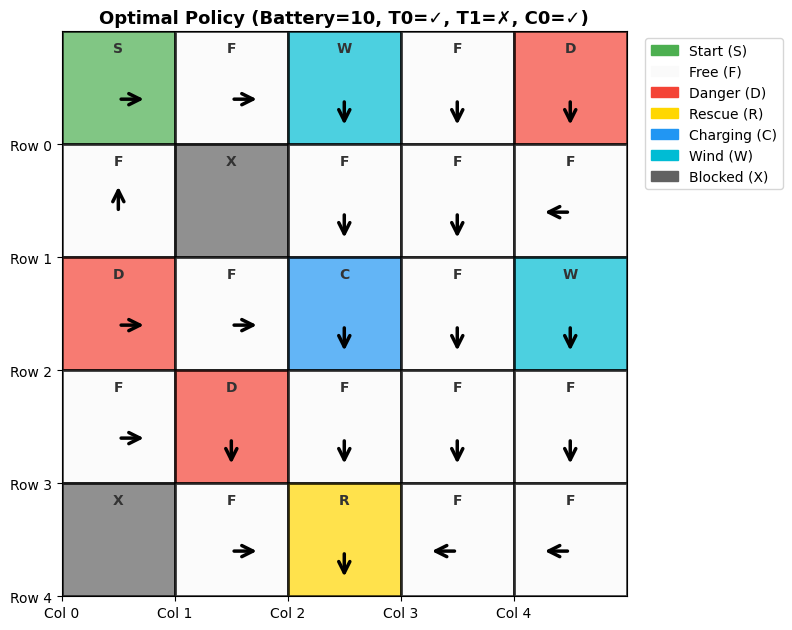


--- Drone Trajectory (following optimal policy) ---


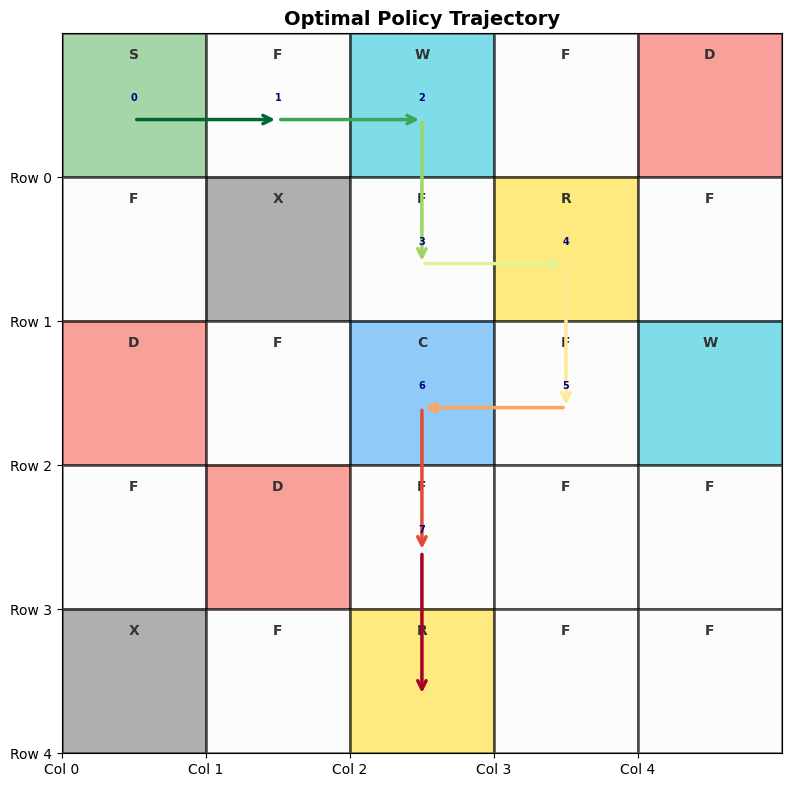

✅ Policy and trajectory plots saved.


In [19]:
# Policy Visualisation (Deliverable 3)
print("\n" + "=" * 60)
print("DELIVERABLE 3: Policy Visualisation")
print("=" * 60)

def plot_policy_grid(env, policy, battery_level, rescue_status, charge_status=None, title_suffix=""):
    """Plot the optimal policy as arrows on the grid.

    Args:
        env: DroneRescueEnv
        policy: dict mapping state → action
        battery_level: fixed battery level to visualise
        rescue_status: tuple of rescue statuses (e.g., (0, 0))
        charge_status: tuple of charging-bonus flags (default: all unclaimed)
        title_suffix: additional text for the title
    """
    if charge_status is None:
        charge_status = tuple([0] * env.num_charging)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Color map for cell types
    cell_colors = {
        'S': '#4CAF50',   # Green
        'F': '#FAFAFA',   # Light gray
        'D': '#F44336',   # Red
        'R': '#FFD700',   # Gold
        'C': '#2196F3',   # Blue
        'W': '#00BCD4',   # Cyan
        'X': '#616161',   # Dark gray
    }

    for r in range(env.rows):
        for c in range(env.cols):
            cell = env._get_cell_type(r, c, rescue_status)
            color = cell_colors.get(cell, '#FFFFFF')

            # Draw cell background
            rect = plt.Rectangle((c, env.rows - 1 - r), 1, 1,
                                  facecolor=color, edgecolor='black',
                                  linewidth=2, alpha=0.7)
            ax.add_patch(rect)

            # Cell label
            ax.text(c + 0.5, env.rows - 1 - r + 0.85, cell,
                    ha='center', va='center', fontsize=10,
                    fontweight='bold', color='#333333')

            # Draw policy arrow
            if (r, c) not in env.blocked_cells:
                state = (r, c, battery_level) + rescue_status + charge_status
                action = policy.get(state)

                if action is not None:
                    cx, cy = c + 0.5, env.rows - 1 - r + 0.4
                    arrow_map = {
                        0: (0, 0.25),    # Up
                        1: (0, -0.25),   # Down
                        2: (-0.25, 0),   # Left
                        3: (0.25, 0),    # Right
                    }

                    if action in arrow_map:
                        dx, dy = arrow_map[action]
                        ax.annotate('', xy=(cx + dx, cy + dy),
                                    xytext=(cx, cy),
                                    arrowprops=dict(arrowstyle='->', color='black',
                                                    lw=2.5, mutation_scale=20))
                    else:  # Hover
                        ax.plot(cx, cy, 'ko', markersize=8)

    ax.set_xlim(0, env.cols)
    ax.set_ylim(0, env.rows)
    ax.set_xticks(range(env.cols))
    ax.set_xticklabels([f'Col {c}' for c in range(env.cols)])
    ax.set_yticks(range(env.rows))
    ax.set_yticklabels([f'Row {r}' for r in range(env.rows - 1, -1, -1)])
    ax.set_aspect('equal')

    rescued_str = ', '.join([f'T{i}={"✓" if s else "✗"}'
                             for i, s in enumerate(rescue_status)])
    charge_str = ', '.join([f'C{i}={"✓" if s else "✗"}'
                            for i, s in enumerate(charge_status)])
    ax.set_title(f'Optimal Policy (Battery={battery_level}, {rescued_str}, {charge_str}){title_suffix}',
                 fontsize=13, fontweight='bold')

    # Legend
    legend_patches = [
        mpatches.Patch(color=cell_colors['S'], label='Start (S)'),
        mpatches.Patch(color=cell_colors['F'], label='Free (F)'),
        mpatches.Patch(color=cell_colors['D'], label='Danger (D)'),
        mpatches.Patch(color=cell_colors['R'], label='Rescue (R)'),
        mpatches.Patch(color=cell_colors['C'], label='Charging (C)'),
        mpatches.Patch(color=cell_colors['W'], label='Wind (W)'),
        mpatches.Patch(color=cell_colors['X'], label='Blocked (X)'),
    ]
    ax.legend(handles=legend_patches, loc='upper left',
              bbox_to_anchor=(1.02, 1), fontsize=10)

    plt.tight_layout()
    return fig


# Plot policies at different battery levels
print("\n--- Policy at Full Battery (both targets unrescued) ---")
fig1 = plot_policy_grid(env, policy_star, MAX_BATTERY, (0, 0))
fig1.savefig('policy_full_battery.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Policy at Low Battery (battery=3, both unrescued) ---")
fig2 = plot_policy_grid(env, policy_star, 3, (0, 0))
fig2.savefig('policy_low_battery.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Policy after first target rescued (battery=10) ---")
fig3 = plot_policy_grid(env, policy_star, 10, (1, 0), (1,))
fig3.savefig('policy_one_rescued.png', dpi=150, bbox_inches='tight')
plt.show()


# Trajectory visualisation
def plot_trajectory(env, trajectory, title="Optimal Policy Trajectory"):
    """Plot the drone's trajectory on the grid."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    cell_colors = {
        'S': '#4CAF50', 'F': '#FAFAFA', 'D': '#F44336',
        'R': '#FFD700', 'C': '#2196F3', 'W': '#00BCD4', 'X': '#616161'
    }

    # Draw grid
    for r in range(env.rows):
        for c in range(env.cols):
            cell = env.grid[r][c]
            color = cell_colors.get(cell, '#FFFFFF')
            rect = plt.Rectangle((c, env.rows - 1 - r), 1, 1,
                                  facecolor=color, edgecolor='black',
                                  linewidth=2, alpha=0.5)
            ax.add_patch(rect)
            ax.text(c + 0.5, env.rows - 1 - r + 0.85, cell,
                    ha='center', va='center', fontsize=10,
                    fontweight='bold', color='#333333')

    # Draw trajectory path
    for i in range(len(trajectory) - 1):
        state = trajectory[i][0]
        next_state = trajectory[i + 1][0]
        r1, c1 = state[0], state[1]
        r2, c2 = next_state[0], next_state[1]

        x1, y1 = c1 + 0.5, env.rows - 1 - r1 + 0.4
        x2, y2 = c2 + 0.5, env.rows - 1 - r2 + 0.4

        # Color gradient from green (start) to red (end)
        progress = i / max(len(trajectory) - 2, 1)
        color = plt.cm.RdYlGn(1 - progress)

        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color,
                                    lw=2.5, mutation_scale=15))

        # Step number
        ax.text(x1, y1 + 0.15, str(i), ha='center', va='center',
                fontsize=7, color='navy', fontweight='bold')

    ax.set_xlim(0, env.cols)
    ax.set_ylim(0, env.rows)
    ax.set_xticks(range(env.cols))
    ax.set_xticklabels([f'Col {c}' for c in range(env.cols)])
    ax.set_yticks(range(env.rows))
    ax.set_yticklabels([f'Row {r}' for r in range(env.rows - 1, -1, -1)])
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold')

    plt.tight_layout()
    return fig


print("\n--- Drone Trajectory (following optimal policy) ---")
fig_traj = plot_trajectory(env, trajectory)
fig_traj.savefig('trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Policy and trajectory plots saved.")

## State-Value Analysis (Deliverable 4)



DELIVERABLE 4: State-Value Heatmap Analysis

--- Heatmap: Full Battery, Both Targets Unrescued ---


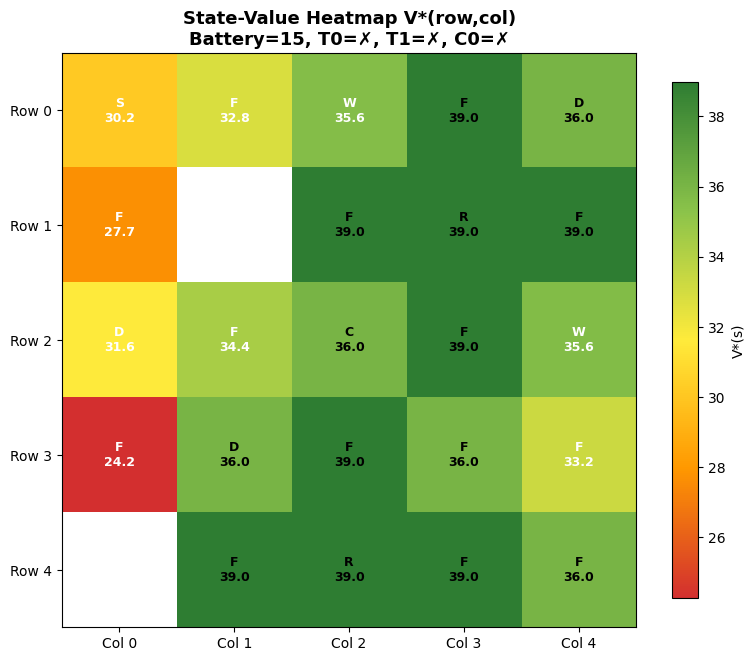


--- Heatmap: Low Battery (3), Both Targets Unrescued ---


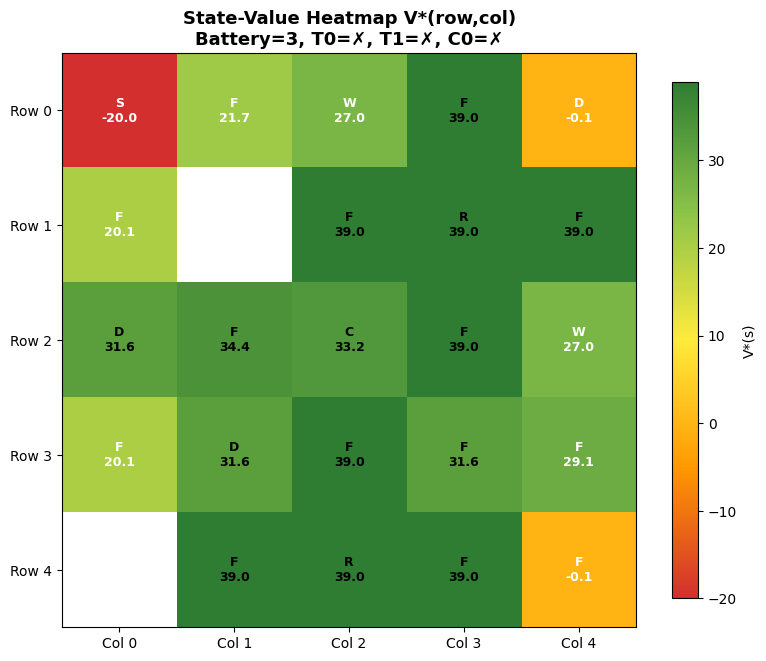


--- Heatmap: Battery=8, Target 0 Rescued ---


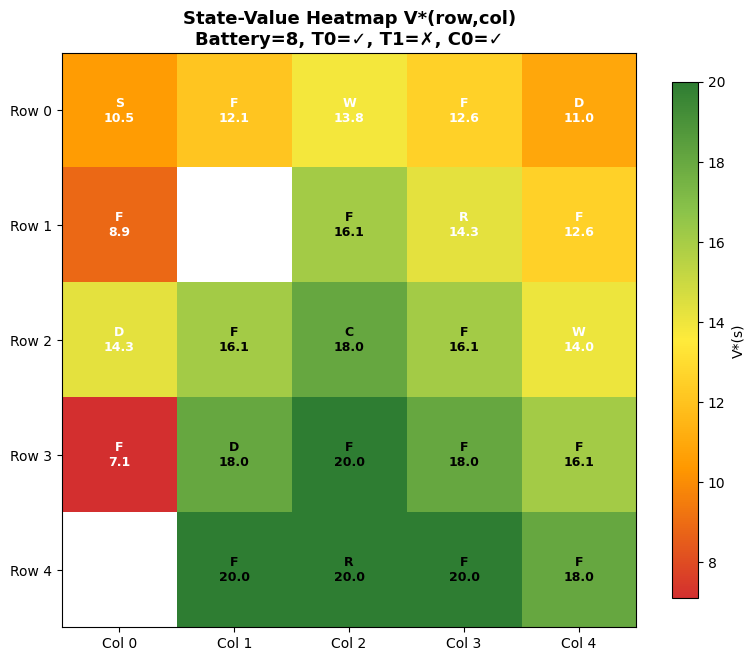


--- Heatmap: Full Battery, Both Rescued (terminal check) ---


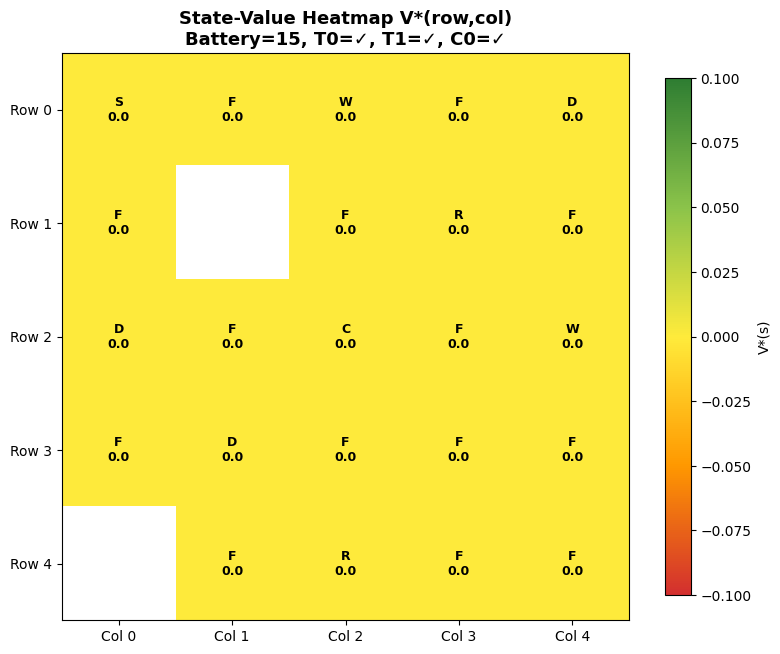


--- State-Value Analysis ---

OBSERVATIONS:

1. Full Battery, Both Unrescued:
   - Cells near rescue targets (1,3) and (4,2) show HIGH values because the drone
     can reach them and collect +20 reward.
   - Danger zone cells (0,4), (2,0), (3,1) show LOWER values due to -10 penalty.
   - The charging station (2,2) has moderate value — it's valuable as a recharge point.

2. Low Battery (3), Both Unrescued:
   - Values DROP dramatically across the grid because the drone has very few moves.
   - Only cells very close to the charging station (2,2) retain positive values.
   - Cells far from the charger have NEGATIVE values — the drone will likely die.
   - This shows the critical importance of battery management.

3. One Target Rescued (battery=8):
   - The value landscape shifts to focus on the remaining target.
   - Cells near the already-rescued target have LOWER values (no reward left there).
   - The drone's policy concentrates on reaching the second target.

4. Both Rescued:
   - A

In [20]:
# State-Value Analysis (Deliverable 4)
print("\n" + "=" * 60)
print("DELIVERABLE 4: State-Value Heatmap Analysis")
print("=" * 60)

def plot_value_heatmap(env, V, battery_level, rescue_status, charge_status=None, title_suffix=""):
    """Plot heatmap of V*(row, col) for fixed battery and rescue status."""
    if charge_status is None:
        charge_status = tuple([0] * env.num_charging)

    value_grid = np.full((env.rows, env.cols), np.nan)

    for r in range(env.rows):
        for c in range(env.cols):
            if (r, c) in env.blocked_cells:
                continue
            state = (r, c, battery_level) + rescue_status + charge_status
            value_grid[r][c] = V.get(state, 0.0)

    fig, ax = plt.subplots(1, 1, figsize=(8, 7))

    # Custom colormap: red (low) → yellow → green (high)
    cmap = LinearSegmentedColormap.from_list('value_cmap',
        ['#D32F2F', '#FF9800', '#FFEB3B', '#8BC34A', '#2E7D32'])

    # Mask NaN for blocked cells
    masked = np.ma.masked_invalid(value_grid)

    im = ax.imshow(masked, cmap=cmap, interpolation='nearest', aspect='equal')
    plt.colorbar(im, ax=ax, label='V*(s)', shrink=0.8)

    # Annotate with values and cell types
    for r in range(env.rows):
        for c in range(env.cols):
            cell = env.grid[r][c]
            if (r, c) in env.blocked_cells:
                ax.text(c, r, 'X\n(blocked)', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
            else:
                val = value_grid[r][c]
                ax.text(c, r, f'{cell}\n{val:.1f}', ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white' if val < np.nanmedian(value_grid) else 'black')

    ax.set_xticks(range(env.cols))
    ax.set_xticklabels([f'Col {c}' for c in range(env.cols)])
    ax.set_yticks(range(env.rows))
    ax.set_yticklabels([f'Row {r}' for r in range(env.rows)])

    rescued_str = ', '.join([f'T{i}={"✓" if s else "✗"}'
                             for i, s in enumerate(rescue_status)])
    charge_str = ', '.join([f'C{i}={"✓" if s else "✗"}'
                            for i, s in enumerate(charge_status)])
    ax.set_title(f'State-Value Heatmap V*(row,col)\nBattery={battery_level}, {rescued_str}, {charge_str}{title_suffix}',
                 fontsize=13, fontweight='bold')

    plt.tight_layout()
    return fig


# Heatmap 1: Full battery, both unrescued
print("\n--- Heatmap: Full Battery, Both Targets Unrescued ---")
fig_h1 = plot_value_heatmap(env, V_star, MAX_BATTERY, (0, 0))
fig_h1.savefig('heatmap_full_battery.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap 2: Low battery (3), both unrescued
print("\n--- Heatmap: Low Battery (3), Both Targets Unrescued ---")
fig_h2 = plot_value_heatmap(env, V_star, 3, (0, 0))
fig_h2.savefig('heatmap_low_battery.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap 3: Medium battery (8), first target rescued
print("\n--- Heatmap: Battery=8, Target 0 Rescued ---")
fig_h3 = plot_value_heatmap(env, V_star, 8, (1, 0), (1,))
fig_h3.savefig('heatmap_one_rescued.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap 4: Full battery, both rescued (should be ~0 everywhere)
print("\n--- Heatmap: Full Battery, Both Rescued (terminal check) ---")
fig_h4 = plot_value_heatmap(env, V_star, MAX_BATTERY, (1, 1), (1,))
fig_h4.savefig('heatmap_all_rescued.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- State-Value Analysis ---")
print("""
OBSERVATIONS:

1. Full Battery, Both Unrescued:
   - Cells near rescue targets (1,3) and (4,2) show HIGH values because the drone
     can reach them and collect +20 reward.
   - Danger zone cells (0,4), (2,0), (3,1) show LOWER values due to -10 penalty.
   - The charging station (2,2) has moderate value — it's valuable as a recharge point.

2. Low Battery (3), Both Unrescued:
   - Values DROP dramatically across the grid because the drone has very few moves.
   - Only cells very close to the charging station (2,2) retain positive values.
   - Cells far from the charger have NEGATIVE values — the drone will likely die.
   - This shows the critical importance of battery management.

3. One Target Rescued (battery=8):
   - The value landscape shifts to focus on the remaining target.
   - Cells near the already-rescued target have LOWER values (no reward left there).
   - The drone's policy concentrates on reaching the second target.

4. Both Rescued:
   - All values are 0 (terminal state — no more rewards to collect).
   - Confirms the environment correctly identifies all-rescued as terminal.
""")
print("✅ Heatmap analysis complete.")

## DP Scalability Discussion (Deliverable 5)


In [21]:
# DP Scalability Discussion (Deliverable 5)
print("\n" + "=" * 60)
print("DELIVERABLE 5: DP Scalability Discussion")
print("=" * 60)

print("""
============================================================
DYNAMIC PROGRAMMING SCALABILITY ANALYSIS
============================================================

1. CURSE OF DIMENSIONALITY
--------------------------------------------------------------
The state space in our MDP grows EXPONENTIALLY with problem complexity:

   |S| = (Grid Positions) × (Battery Levels) × 2^(Rescue Targets)
         × 2^(Charging Stations)

   Current (5×5, bat=15, 2 targets, 1 charger):
       23 × 16 × 4 × 2 = 2,944 states → DP runs in seconds ✅

   Scaled up scenarios:
   ┌────────────────────────────────┬────────────┬──────────────┐
   │ Scenario                       │ States     │ DP Feasible? │
   ├────────────────────────────────┼────────────┼──────────────┤
   │ 5×5, bat=15, 2 targets         │ ~3,000     │ ✅ Seconds    │
   │ 10×10, bat=20, 5 targets       │ ~672,000   │ ⚠️ Minutes   │
   │ 20×20, bat=30, 10 targets      │ ~12.6B     │ ❌ Impossible │
   │ 50×50, bat=50, 20 targets      │ ~134T      │ ❌ Impossible │
   └────────────────────────────────┴────────────┴──────────────┘

   Each added rescue target DOUBLES the state space.
   Each charging-station bonus flag DOUBLES it again.
   Each added battery level adds (Positions × 2^targets) states.
   Larger grids scale quadratically in positions.


2. WHY DP BECOMES IMPRACTICAL
--------------------------------------------------------------
   a) MEMORY: Must store V(s) for EVERY state — billions of entries.
   b) COMPUTATION: Each iteration sweeps ALL states × ALL actions.
      For 672K states × 5 actions = 3.36M transition computations per iteration.
   c) TRANSITION MODEL: Must have EXACT P(s'|s,a) for all state-action pairs.
      In real-world, the transition model is often unknown.
   d) ITERATIONS: Though each iteration is O(|S|×|A|), convergence may
      require hundreds of iterations.


3. HOW DEEP RL METHODS COULD HELP
--------------------------------------------------------------
   Deep RL uses FUNCTION APPROXIMATION (neural networks) to estimate
   V(s) or π(s) WITHOUT enumerating all states:

   a) DQN (Deep Q-Network):
      - Neural network takes state as input, outputs Q(s,a) for all actions.
      - Learns from sampled transitions (no need for complete model).
      - Can handle continuous/large discrete state spaces.

   b) Policy Gradient (PPO, A3C):
      - Neural network directly outputs probability of each action.
      - More stable for complex environments.
      - Can handle continuous action spaces (variable speed, altitude).

   c) Key advantage: GENERALIZATION
      - DP computes V(s) independently for each state.
      - Neural nets generalize: similar states get similar values automatically.
      - A drone at (3,4) with battery=10 and (3,4) with battery=11 should
        have similar values — Deep RL leverages this, DP does not.


4. RELATION TO REAL-WORLD AUTONOMOUS DRONE SYSTEMS
--------------------------------------------------------------
   Real-world drones face challenges far beyond our grid world:

   a) CONTINUOUS STATE SPACE:
      - Position: (x, y, z) in continuous 3D space
      - Velocity, acceleration, orientation (6+ DOF)
      - DP cannot discretize all of these without explosion.

   b) PARTIAL OBSERVABILITY:
      - Drone has limited camera/sensor range.
      - Cannot see the entire grid — must infer hidden states.
      - Requires POMDP (Partially Observable MDP) → even harder for DP.

   c) DYNAMIC ENVIRONMENTS:
      - Weather changes (wind direction/strength varies over time).
      - New obstacles appear (aftershocks, fire spread).
      - Civilians may move or change status.
      - Our static grid is a major simplification.

   d) MULTI-AGENT COORDINATION:
      - Multiple drones must coordinate without collision.
      - Joint state space = product of individual spaces → exponential blowup.

   CONCLUSION:
   DP provides the THEORETICAL FOUNDATION and guarantees optimality for
   small, fully-known environments. For real-world drone systems, Deep RL
   methods (or hybrid approaches) are necessary to handle scale, uncertainty,
   and continuous dynamics. Our 5×5 grid demonstrates the principles; scaling
   to reality requires the tools of modern deep reinforcement learning.

============================================================
""")


DELIVERABLE 5: DP Scalability Discussion

DYNAMIC PROGRAMMING SCALABILITY ANALYSIS

1. CURSE OF DIMENSIONALITY
--------------------------------------------------------------
The state space in our MDP grows EXPONENTIALLY with problem complexity:

   |S| = (Grid Positions) × (Battery Levels) × 2^(Rescue Targets)
         × 2^(Charging Stations)

   Current (5×5, bat=15, 2 targets, 1 charger):
       23 × 16 × 4 × 2 = 2,944 states → DP runs in seconds ✅

   Scaled up scenarios:
   ┌────────────────────────────────┬────────────┬──────────────┐
   │ Scenario                       │ States     │ DP Feasible? │
   ├────────────────────────────────┼────────────┼──────────────┤
   │ 5×5, bat=15, 2 targets         │ ~3,000     │ ✅ Seconds    │
   │ 10×10, bat=20, 5 targets       │ ~672,000   │ ⚠️ Minutes   │
   │ 20×20, bat=30, 10 targets      │ ~12.6B     │ ❌ Impossible │
   │ 50×50, bat=50, 20 targets      │ ~134T      │ ❌ Impossible │
   └────────────────────────────────┴────────────┴──────

## Summary


In [22]:
# Summary
print("=" * 60)
print("ASSIGNMENT PART 2 — COMPLETE SUMMARY")
print("=" * 60)
print(f"""
Group ID           : 151
Grid               : 5×5
Algorithm          : Value Iteration
Discount (γ)       : {GAMMA}
Threshold (θ)      : {THETA}
Convergence Iters  : {vi_info['iterations']}
Runtime            : {vi_info['runtime_seconds']:.2f} seconds
Final Delta        : {vi_info['final_delta']:.6f}
Total States       : {vi_info['num_states']}
V*(start)          : {V_star.get(initial_state, 0):.4f}
Optimal First Move : {ACTION_LABELS.get(policy_star.get(initial_state), 'N/A')}

Deliverables:
  ✅ 1. Custom Drone Rescue Environment (1 mark)
  ✅ 2. Value Iteration — V* and π* computed (2 marks)
  ✅ 3. Policy Visualisation — arrows + trajectory (1 mark)
  ✅ 4. State-Value Heatmap Analysis (1 mark)
  ✅ 5. DP Scalability Discussion (1 mark)

Files saved:
  - convergence_plot.png
  - policy_full_battery.png
  - policy_low_battery.png
  - policy_one_rescued.png
  - trajectory.png
  - heatmap_full_battery.png
  - heatmap_low_battery.png
  - heatmap_one_rescued.png
  - heatmap_all_rescued.png
""")
print("🎉 Assignment Part 2 Complete!")

ASSIGNMENT PART 2 — COMPLETE SUMMARY

Group ID           : 151
Grid               : 5×5
Algorithm          : Value Iteration
Discount (γ)       : 0.95
Threshold (θ)      : 0.001
Convergence Iters  : 11
Runtime            : 1.19 seconds
Final Delta        : 0.000066
Total States       : 2944
V*(start)          : 30.1699
Optimal First Move : Right

Deliverables:
  ✅ 1. Custom Drone Rescue Environment (1 mark)
  ✅ 2. Value Iteration — V* and π* computed (2 marks)
  ✅ 3. Policy Visualisation — arrows + trajectory (1 mark)
  ✅ 4. State-Value Heatmap Analysis (1 mark)
  ✅ 5. DP Scalability Discussion (1 mark)

Files saved:
  - convergence_plot.png
  - policy_full_battery.png
  - policy_low_battery.png
  - policy_one_rescued.png
  - trajectory.png
  - heatmap_full_battery.png
  - heatmap_low_battery.png
  - heatmap_one_rescued.png
  - heatmap_all_rescued.png

🎉 Assignment Part 2 Complete!
